In [3]:
import pandas as pd

In [74]:
context = pd.read_csv('../../data/Train-Test Splits/Context/train.csv')
context['time_zone'] = context.time_zone.fillna('Undefined')
context['valence'] = context.valence.fillna(context.valence.mean())
context['instrumentalness'] = context.instrumentalness.fillna(context.instrumentalness.mean())
context['liveness'] = context.liveness.fillna(context.liveness.mean())
context['speechiness'] = context.speechiness.fillna(context.speechiness.mean())
context['danceability'] = context.danceability.fillna(context.danceability.mean())
context['acousticness'] = context.acousticness.fillna(context.acousticness.mean())
context['energy'] = context.energy.fillna(context.energy.mean())
context['mode'] = context['mode'].fillna(context['mode'].mean())
context['key'] = context['key'].fillna(context['key'].mean())

language_mapping = {
    'en': 'English',
    'en-GB': 'English (UK)',
    'en-gb': 'English (UK)',
    'es': 'Spanish',
    'fr': 'French',
    'de': 'German',
    'it': 'Italian',
    'ja': 'Japanese',
    'ko': 'Korean',
    'pt': 'Portuguese',
    'ru': 'Russian',
    'zh-Hans': 'Chinese (Simplified)',
    'zh-tw': 'Chinese (Traditional)',
    'ar': 'Arabic',
    'nl': 'Dutch',
    'tr': 'Turkish',
    'pl': 'Polish',
    'sv': 'Swedish',
    'fi': 'Finnish',
    'no': 'Norwegian',
    'da': 'Danish',
    'id': 'Indonesian',
    'hu': 'Hungarian',
    'cs': 'Czech',
    'ca': 'Catalan',
    'eu': 'Basque',
    'gl': 'Galician',
    'uk': 'Ukrainian',
    'xx-lc': 'Unknown/Hidden'
}

timezone_mapping = {
    # UTC -11:00 to -09:00
    "International Date Line West": "UTC-11:00",
    "Midway Island": "UTC-11:00",
    "Hawaii": "UTC-10:00",
    "Alaska": "UTC-09:00",

    # UTC -08:00 to -06:00 (North America West/Central)
    "Pacific Time (US & Canada)": "UTC-08:00",
    "Arizona": "UTC-07:00",
    "Chihuahua": "UTC-07:00",
    "Mountain Time (US & Canada)": "UTC-07:00",
    "Central America": "UTC-06:00",
    "Central Time (US & Canada)": "UTC-06:00",
    "Guadalajara": "UTC-06:00",
    "Mexico City": "UTC-06:00",
    "Monterrey": "UTC-06:00",
    "Saskatchewan": "UTC-06:00",

    # UTC -05:00 to -03:00 (Americas East)
    "America/Chicago": "UTC-05:00",
    "America/Detroit": "UTC-05:00",
    "America/New_York": "UTC-05:00",
    "Bogota": "UTC-05:00",
    "Eastern Time (US & Canada)": "UTC-05:00",
    "Indiana (East)": "UTC-05:00",
    "Lima": "UTC-05:00",
    "Quito": "UTC-05:00",
    "America/Sao_Paulo": "UTC-03:00",
    "Atlantic Time (Canada)": "UTC-04:00",
    "Caracas": "UTC-04:00",
    "La Paz": "UTC-04:00",
    "Santiago": "UTC-04:00",
    "Brasilia": "UTC-03:00",
    "Buenos Aires": "UTC-03:00",
    "Greenland": "UTC-03:00",
    "Newfoundland": "UTC-03:30",

    # UTC -02:00 to +00:00 (Atlantic / West Europe)
    "Mid-Atlantic": "UTC-02:00",
    "Azores": "UTC-01:00",
    "Casablanca": "UTC+00:00",
    "Dublin": "UTC+00:00",
    "Edinburgh": "UTC+00:00",
    "Europe/London": "UTC+00:00",
    "Lisbon": "UTC+00:00",
    "London": "UTC+00:00",

    # UTC +01:00 to +02:00 (Europe / Africa)
    "Amsterdam": "UTC+01:00",
    "Belgrade": "UTC+01:00",
    "Berlin": "UTC+01:00",
    "Bern": "UTC+01:00",
    "Bratislava": "UTC+01:00",
    "Brussels": "UTC+01:00",
    "Budapest": "UTC+01:00",
    "Copenhagen": "UTC+01:00",
    "Ljubljana": "UTC+01:00",
    "Madrid": "UTC+01:00",
    "Paris": "UTC+01:00",
    "Prague": "UTC+01:00",
    "Rome": "UTC+01:00",
    "Stockholm": "UTC+01:00",
    "Vienna": "UTC+01:00",
    "Warsaw": "UTC+01:00",
    "West Central Africa": "UTC+01:00",
    "Zagreb": "UTC+01:00",
    "Athens": "UTC+02:00",
    "Cairo": "UTC+02:00",
    "Helsinki": "UTC+02:00",
    "Istanbul": "UTC+02:00",
    "Jerusalem": "UTC+02:00",
    "Kyiv": "UTC+02:00",
    "Pretoria": "UTC+02:00",
    "Riga": "UTC+02:00",
    "Sofia": "UTC+02:00",
    "Vilnius": "UTC+02:00",

    # UTC +03:00 to +05:00 (Middle East / Russia / South Asia)
    "Baghdad": "UTC+03:00",
    "Europe/Minsk": "UTC+03:00",
    "Kuwait": "UTC+03:00",
    "Minsk": "UTC+03:00",
    "Moscow": "UTC+03:00",
    "Riyadh": "UTC+03:00",
    "St. Petersburg": "UTC+03:00",
    "Tehran": "UTC+03:30",
    "Abu Dhabi": "UTC+04:00",
    "Muscat": "UTC+04:00",
    "Tbilisi": "UTC+04:00",
    "Yerevan": "UTC+04:00",
    "Ekaterinburg": "UTC+05:00",
    "Islamabad": "UTC+05:00",
    "Mumbai": "UTC+05:30",
    "New Delhi": "UTC+05:30",
    "Chennai": "UTC+05:30",
    "Kathmandu": "UTC+05:45",

    # UTC +06:00 to +09:00 (Central / East Asia)
    "Almaty": "UTC+06:00",
    "Astana": "UTC+06:00",
    "Bangkok": "UTC+07:00",
    "Jakarta": "UTC+07:00",
    "Novosibirsk": "UTC+07:00",
    "Beijing": "UTC+08:00",
    "Hong Kong": "UTC+08:00",
    "Irkutsk": "UTC+08:00",
    "Kuala Lumpur": "UTC+08:00",
    "Singapore": "UTC+08:00",
    "Taipei": "UTC+08:00",
    "Perth": "UTC+08:00",
    "Osaka": "UTC+09:00",
    "Sapporo": "UTC+09:00",
    "Seoul": "UTC+09:00",
    "Tokyo": "UTC+09:00",
    "Yakutsk": "UTC+09:00",

    # UTC +10:00 to +12:00 (Oceania)
    "Brisbane": "UTC+10:00",
    "Canberra": "UTC+10:00",
    "Hobart": "UTC+10:00",
    "Melbourne": "UTC+10:00",
    "Pacific/Guam": "UTC+10:00",
    "Sydney": "UTC+10:00",
    "New Caledonia": "UTC+11:00",
    "Auckland": "UTC+12:00",
    "Wellington": "UTC+12:00",
    "Adelaide": "UTC+09:30",
    "Harare": "UTC+02:00",
    "Monrovia": "UTC+00:00",
    
    # Unmapped
    "Undefined": "Unknown"
}
context['lang'] = context.lang.replace(language_mapping)
context['tweet_lang'] = context.tweet_lang.replace(language_mapping)
context['time_zone'] = context.time_zone.replace(timezone_mapping)
context['created_at'] = context.created_at.apply(pd.to_datetime)

context_column_map = {
    "user_id": "user_id",
    "track_id": "track_id",
    "hashtag": "Hash tags",
    "created_at": "Timestamp of the activity",
    "score": "Calculated value for the post",
    "lang": "Primary language for the user profile",
    "tweet_lang": "Primary language for the specific post",
    "time_zone": "Regional setting for the user",
    "instrumentalness": "Probability that the track contains no vocals",
    "liveness": "Likelihood the recording was a live performance",
    "speechiness": "Presence of spoken words",
    "danceability": "Suitability for dancing based on tempo and beat",
    "valence": "Musical positiveness",
    "loudness": "Overall volume in decibels",
    "tempo": "Speed of the track in beats per minute",
    "acousticness": "Likelihood that the track is not electronic",
    "energy": "Perceived intensity and activity level",
    "mode": "Major or minor status of the track",
    "key": "Musical scale of the track",
    "rating": "User-assigned or system-generated preference score"
}

context = context.rename(columns=context_column_map)

In [33]:
context.isna().sum()

user_id                                               0
track_id                                              0
Hash tags                                             0
Timestamp of the activity                             0
Calculated value for the post                         0
Primary language for the user profile                 0
Primary language for the specific post                0
Regional setting for the user                         0
Probability that the track contains no vocals         0
Likelihood the recording was a live performance       0
Presence of spoken words                              0
Suitability for dancing based on tempo and beat       0
Musical positiveness                                  0
Overall volume in decibels                            0
Speed of the track in beats per minute                0
Likelihood that the track is not electronic           0
Perceived intensity and activity level                0
Major or minor status of the track              

In [70]:
context.head()

,user_id,track_id,Hash tags,Timestamp of the activity,Calculated value for the post,Primary language for the user profile,Primary language for the specific post,Regional setting for the user,Probability that the track contains no vocals,Likelihood the recording was a live performance,Presence of spoken words,Suitability for dancing based on tempo and beat,Musical positiveness,Overall volume in decibels,Speed of the track in beats per minute,Likelihood that the track is not electronic,Perceived intensity and activity level,Major or minor status of the track,Musical scale of the track,User-assigned or system-generated preference score
0,823214346,b129f3e0a0bdc1e61c57ce994f9d2932,kiss92,2014-01-01 05:59:38,0.8,English,English,UTC+08:00,0.000000,0.0764,0.0240,0.549,0.320,-7.698,80.133,0.341000,0.408,1.0,8.0,1
1,823214346,64b30f6ac1acecb7cef9dc890e1c3ea7,kiss92,2014-01-01 06:06:15,0.8,English,English,UTC+08:00,0.018300,0.1090,0.0407,0.585,0.380,-6.440,127.955,0.000357,0.759,1.0,9.0,1
2,823214346,cc1a46ee0446538ecf6b65db01c30cd8,kiss92,2014-01-01 06:11:07,0.8,English,English,UTC+08:00,0.000000,0.0931,0.0345,0.489,0.270,-4.197,92.526,0.077000,0.846,1.0,4.0,1
3,823214346,dbbd8525c1bc48cc791bfe618b74bac6,kiss92,2014-01-01 06:19:43,0.8,English,English,UTC+08:00,0.000000,0.0909,0.0314,0.607,0.576,-4.217,122.010,0.032700,0.934,1.0,3.0,1
4,823214346,dbdbb866939c1ab1dfd0d5cfac740eaa,kiss92,2014-01-01 06:23:47,0.8,English,English,UTC+08:00,0.000005,0.0951,0.1730,0.507,0.768,-5.581,99.252,0.081800,0.923,1.0,0.0,1


<Axes: title={'center': 'Activity distribution by post create time'}, xlabel='Timestamp of the activity'>

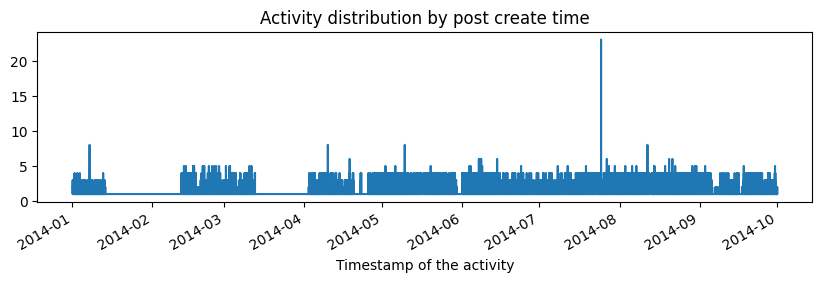

In [78]:
context.groupby('Timestamp of the activity').size().plot(figsize=(10,2.5), title="Activity distribution by post create time")